In [42]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [43]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/5/PBMC5_clustering.h5ad"

adata = sc.read(dir)

In [44]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 78900 × 20061
  var:	'n_cells'
  2 modalities
    rna:	78876 x 20053
      obs:	'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'dendrogram_leiden_res1', 'final_anno_colors', 'final_broad_colors', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'manual_celltype_annotation_1_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	24 x 8
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

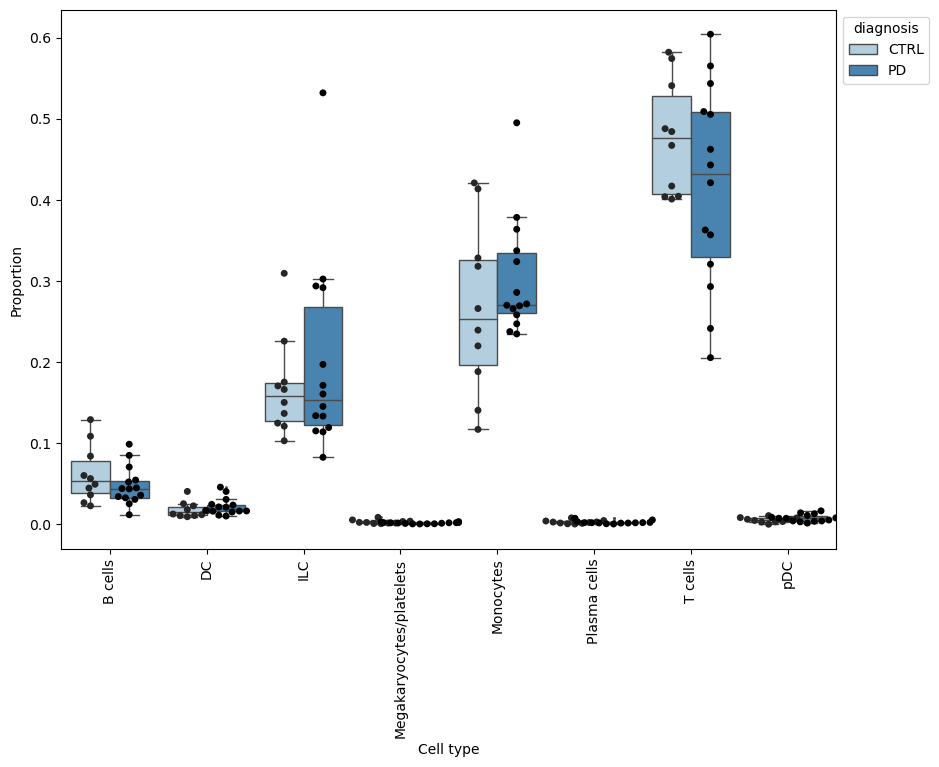

In [45]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"color": "red"},
)
plt.show()

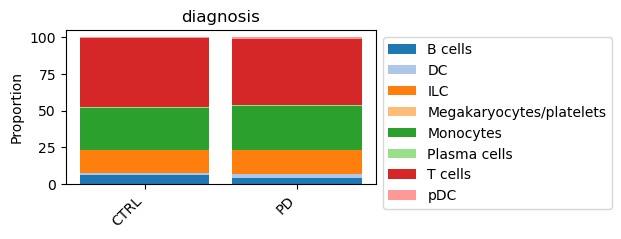

In [46]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [47]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'PD'], dtype='object')

In [48]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:21<00:00, 135.33it/s, 127 steps of size 2.80e-02. acc. prob=0.86]


In [49]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.498,0.181,0.147,0.5158,180.432256,0.0
DC,0.0,-0.305,0.417,0.132,0.4829,82.628561,0.0
ILC,0.0,-0.220,0.287,0.084,0.4082,556.883129,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,23.768363,0.0
Monocytes,0.0,-0.098,0.376,0.108,0.4852,866.407538,0.0
Plasma cells,0.0,-0.367,0.431,0.144,0.4761,25.390000,0.0
T cells,0.0,-0.448,0.015,0.145,0.7611,1512.252281,0.0
pDC,0.0,-0.268,0.524,0.147,0.4802,38.758706,0.0


In [50]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). At FDR 0.05

In [51]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
credible = sccoda_model.credible_effects(sccoda_data, modality_key="coda")
credible

Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 Plasma cells                False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

In [52]:
# identify significant cell types for downstream analyses

# dictionary for stars
significance_mapping = {
    celltype: "*"
    for (effect, celltype), is_sig in credible.items()
    if is_sig
}

In [53]:
significance_mapping

{}

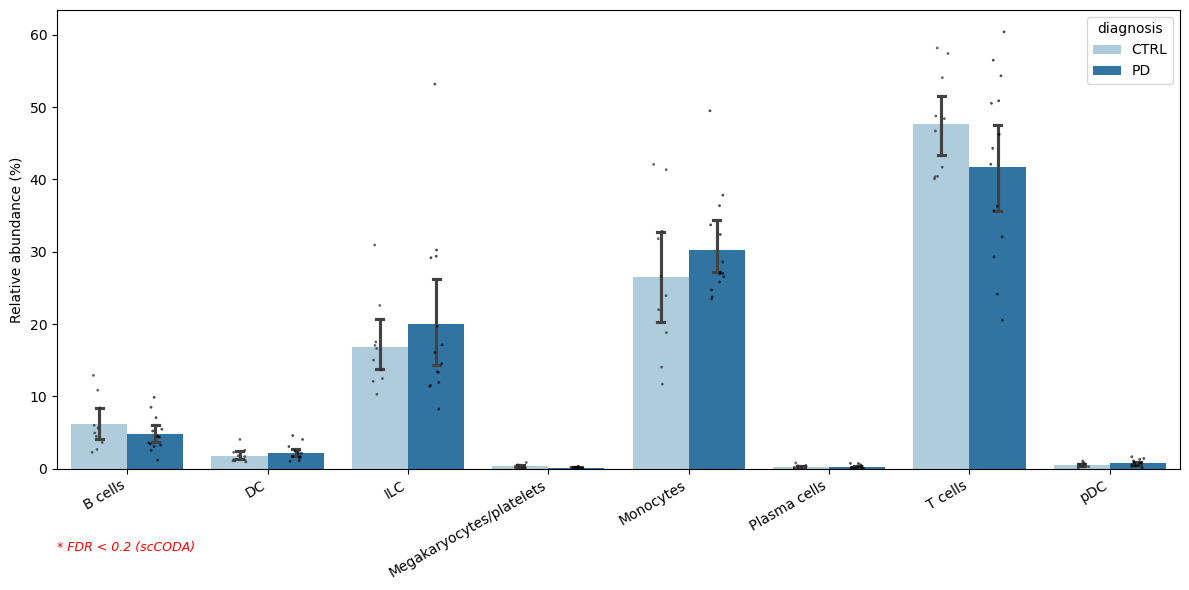

In [54]:
# plot relative abundances of cell types across the two conditions
coda = sccoda_data["coda"]

# Build relative-abundance long-format dataframe in one chain
plot_df = (
    pd.DataFrame(coda.X, index=coda.obs_names, columns=coda.var_names)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
    .assign(diagnosis=coda.obs["diagnosis"].values)
    .reset_index(names="sample")
    .melt(id_vars=["sample", "diagnosis"], var_name="cell_type", value_name="rel_abundance")
)

cell_types = plot_df["cell_type"].unique().tolist()

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    errorbar=("ci", 95), capsize=0.1, palette="Paired", ax=ax
)
sns.stripplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    dodge=True, color="black", alpha=0.7, size=2, legend=False, ax=ax
)

# Significance annotations 
PAD      = 1.2   # gap between bar top and bracket
TXT_PAD  = 0.4   # gap between bracket and asterisk

for ct, label in significance_mapping.items():
    x   = cell_types.index(ct)
    top = plot_df.loc[plot_df["cell_type"] == ct, "rel_abundance"].max()
    y_bracket = top + PAD
    y_text    = y_bracket + TXT_PAD

    # horizontal bracket line
    ax.plot(
        [x - 0.2, x + 0.2], [y_bracket, y_bracket],
        color="black", linewidth=1.2, solid_capstyle="round"
    )
    # asterisk with bold weight + contrasting background box
    ax.text(
        x, y_text, label,
        ha="center", va="bottom", fontsize=16, fontweight="bold", color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    )

ax.annotate(
    "* FDR < 0.2 (scCODA)",
    xy=(0, -0.18), xycoords="axes fraction",
    fontsize=9, color="red", style="italic"
)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



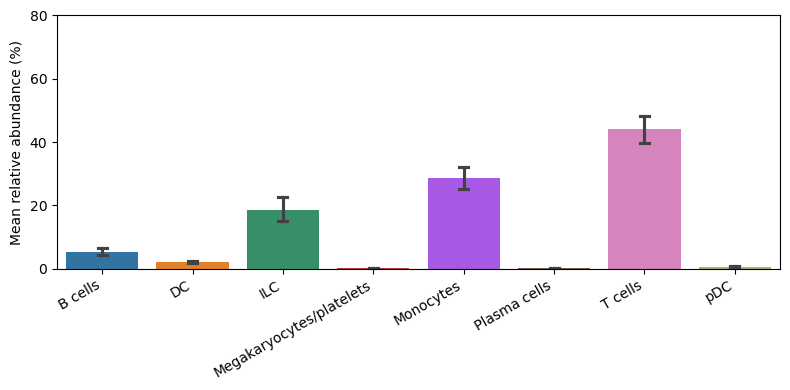

In [ ]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

In [56]:
# recalculate relative abundance just for controls samples

ctrl_data = adata[adata.obs["diagnosis"] == "CTRL"]

ctrl_plot_df = (
    ctrl_data.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

ctrl_plot_df

,sample,celltypist_cell_label_coarse,count,rel_abundance
0,CTRL1,B cells,238,5.626478
1,CTRL1,DC,71,1.678487
2,CTRL1,ILC,435,10.283688
3,CTRL1,Megakaryocytes/platelets,6,0.141844
4,CTRL1,Monocytes,1749,41.347518
...,...,...,...,...
75,CTRL10,Megakaryocytes/platelets,6,0.334448
76,CTRL10,Monocytes,252,14.046823
77,CTRL10,Plasma cells,1,0.055741
78,CTRL10,T cells,875,48.773690


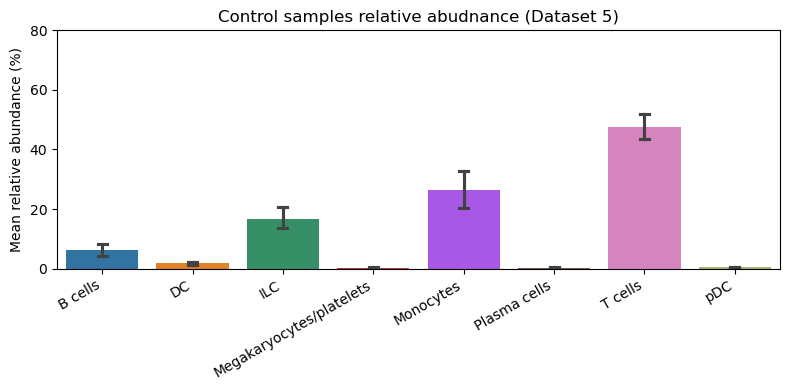

In [57]:
# plot just the control samples:

plt.figure(figsize=(8, 4))
sns.barplot(
    data=ctrl_plot_df,
    x="celltypist_cell_label_coarse",
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.title("Control samples relative abudnance (Dataset 5)")
plt.tight_layout()
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.show()


In [58]:
# check that the control relative abdunaces values add up to 100% for each sample

ctrl_plot_df.groupby("sample")["rel_abundance"].sum()

sample
CTRL1     100.0
CTRL2     100.0
CTRL3     100.0
CTRL4     100.0
CTRL5     100.0
CTRL6     100.0
CTRL7     100.0
CTRL8     100.0
CTRL9     100.0
CTRL10    100.0
Name: rel_abundance, dtype: float64

In [59]:
# Compare numerical differences between all samples and control-only samples

# Calculate mean relative abundance by cell type
all_samples_mean = plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()
ctrl_only_mean = ctrl_plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "All samples (%)": all_samples_mean,
    "Control only (%)": ctrl_only_mean,
})
comparison_df["Difference (%)"] = comparison_df["All samples (%)"] - comparison_df["Control only (%)"]
comparison_df = comparison_df.sort_values("Difference (%)", ascending=False)

print("Cell type composition comparison:\n")
print(comparison_df.round(2))


Cell type composition comparison:

                              All samples (%)  Control only (%)  \
celltypist_cell_label_coarse                                      
Monocytes                               28.71             26.51   
ILC                                     18.64             16.82   
DC                                       2.03              1.78   
pDC                                      0.66              0.52   
Plasma cells                             0.27              0.27   
Megakaryocytes/platelets                 0.21              0.30   
B cells                                  5.33              6.17   
T cells                                 44.15             47.62   

                              Difference (%)  
celltypist_cell_label_coarse                  
Monocytes                               2.19  
ILC                                     1.82  
DC                                      0.25  
pDC                                     0.14  
Plasma cells

In [60]:
# redo composition analysis with fine annotations 

sccoda_model2 = pt.tl.Sccoda()
sccoda_data2 = sccoda_model2.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_fine",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data2

MuData object with n_obs × n_vars = 78900 × 20071
  var:	'n_cells'
  2 modalities
    rna:	78876 x 20053
      obs:	'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'dendrogram_leiden_res1', 'final_anno_colors', 'final_broad_colors', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'manual_celltype_annotation_1_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	24 x 18
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

In [61]:
# run scCODA model
sccoda_data2 = sccoda_model2.prepare(
    sccoda_data2,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model2.run_nuts(sccoda_data2, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:09<00:00, 158.08it/s, 63 steps of size 6.20e-02. acc. prob=0.70]


In [62]:
sccoda_data2["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,0.0,0.000,0.000,0.000,0.0000,17.554403,0.0
CD16+ NK cells,0.0,-0.113,0.244,0.072,0.4898,579.001338,0.0
Classical monocytes,0.0,-0.049,0.332,0.108,0.6369,672.703581,0.0
DC1,0.0,-0.262,0.283,0.098,0.5031,16.107819,0.0
DC2,0.0,-0.186,0.323,0.096,0.5007,77.424618,0.0
MAIT cells,0.0,-0.322,0.200,0.097,0.5105,43.567209,0.0
Megakaryocytes/platelets,0.0,-0.316,0.232,0.104,0.5047,20.974445,0.0
Memory B cells,0.0,-0.279,0.241,0.093,0.4885,52.841919,0.0
Naive B cells,0.0,-0.314,0.159,0.091,0.5015,130.883130,0.0


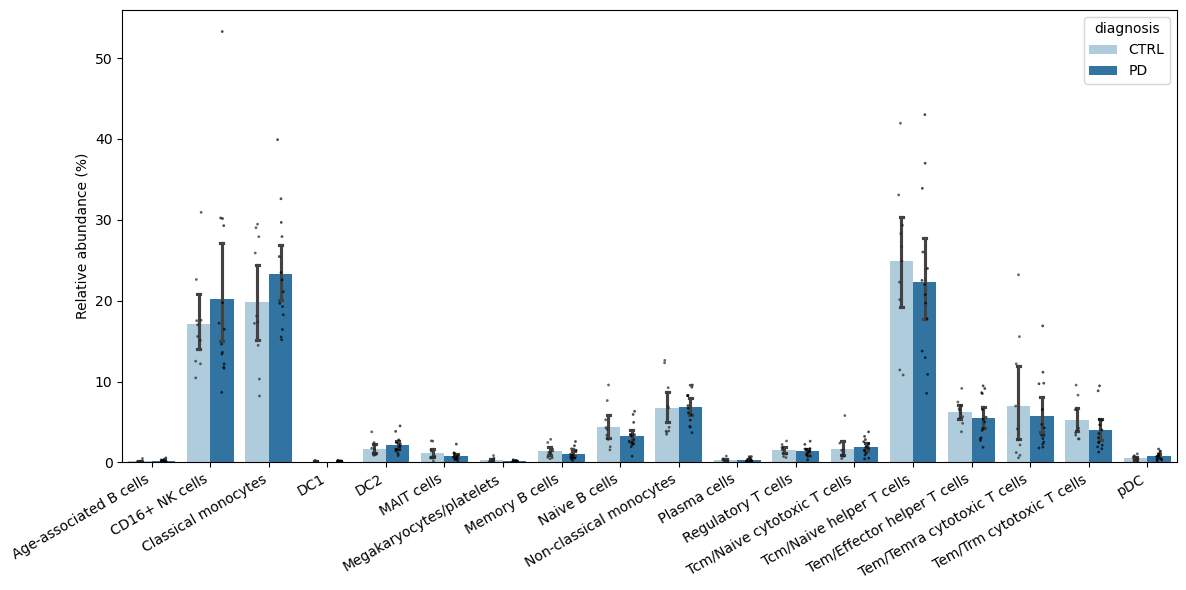

In [63]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data2["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [64]:
sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC1                            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Plasma cells                   False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                 

In [65]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model2.set_fdr(sccoda_data2, 0.2)
credible = sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")
credible


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC1                            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Plasma cells                   False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                 

In [66]:
sccoda_model2.set_fdr(sccoda_data2, 0.05)


In [67]:
# now try sccoda with filtering out rare cell types (those with mean relative abundance < 1%)

cell_type_col = "celltypist_cell_label_fine"
sample_col    = "sample"
min_mean_prop = 0.01   # 1%

# Per-sample cell-type counts -> per-sample proportions -> mean across samples
counts = (
    adata.obs
    .groupby([sample_col, cell_type_col])
    .size()
    .unstack(fill_value=0)
)
props      = counts.div(counts.sum(axis=1), axis=0)
mean_props = props.mean(axis=0).sort_values(ascending=False)

keep    = mean_props[mean_props >= min_mean_prop].index.tolist()
dropped = mean_props[mean_props <  min_mean_prop].index.tolist()

print(f"Keeping {len(keep)} cell types (mean per-sample proportion ≥ {min_mean_prop:.0%}):")
print(mean_props.loc[keep].round(4).to_string())
print(f"\nDropping {len(dropped)} rare cell types:")
print(mean_props.loc[dropped].round(4).to_string())

# Filter AnnData to retained cell types
adata_filt = adata[adata.obs[cell_type_col].isin(keep)].copy()
# (optional) drop unused category levels so scCODA doesn't see empty columns
adata_filt.obs[cell_type_col] = adata_filt.obs[cell_type_col].astype(str).astype("category")

Keeping 12 cell types (mean per-sample proportion ≥ 1%):
celltypist_cell_label_fine
Tcm/Naive helper T cells       0.2341
Classical monocytes            0.2188
CD16+ NK cells                 0.1891
Non-classical monocytes        0.0683
Tem/Temra cytotoxic T cells    0.0629
Tem/Effector helper T cells    0.0581
Tem/Trm cytotoxic T cells      0.0450
Naive B cells                  0.0373
DC2                            0.0193
Tcm/Naive cytotoxic T cells    0.0176
Regulatory T cells             0.0144
Memory B cells                 0.0119

Dropping 6 rare cell types:
celltypist_cell_label_fine
MAIT cells                  0.0093
pDC                         0.0066
Plasma cells                0.0027
Megakaryocytes/platelets    0.0021
Age-associated B cells      0.0015
DC1                         0.0010


In [68]:
sccoda_model = pt.tl.Sccoda()
sccoda_data_filt = sccoda_model.load(
    adata_filt,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier=cell_type_col,
    sample_identifier=sample_col,
    covariate_obs=["diagnosis"],
)

sccoda_data_filt = sccoda_model.prepare(
    sccoda_data_filt,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic",
)
sccoda_model.run_nuts(sccoda_data_filt, modality_key="coda", rng_key=1234)

# effects
sccoda_data_filt["coda"].varm["effect_df_diagnosis[T.PD]"]

# FDR 0.2 for sensitivity
sccoda_model.set_fdr(sccoda_data_filt, 0.2)
print(sccoda_model.credible_effects(sccoda_data_filt, modality_key="coda"))

# back to 0.05
sccoda_model.set_fdr(sccoda_data_filt, 0.05)
print(sccoda_model.credible_effects(sccoda_data_filt, modality_key="coda"))

sample: 100%|██████████| 11000/11000 [00:54<00:00, 201.95it/s, 63 steps of size 5.87e-02. acc. prob=0.74]


Covariate        Cell Type                  
diagnosis[T.PD]  CD16+ NK cells                 False
                 Classical monocytes            False
                 DC2                            False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
Name: Final Parameter, dtype: bool
Covariate        Cell Type                  
diagnosis[T.PD]  CD16+ NK cells                 False
                 Classical monocytes            False
                 DC2                            False
                 Memory B cells                 False
           

In [69]:
# none are significant still

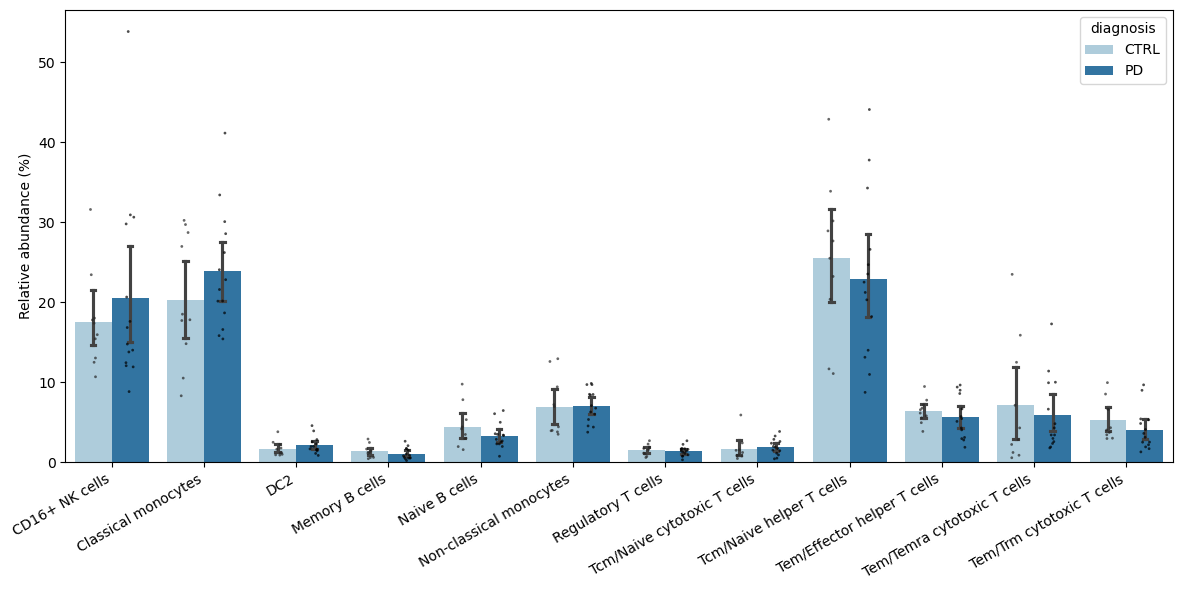

In [70]:
# plot relative abundances again with filtered cell types

coda = sccoda_data_filt["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


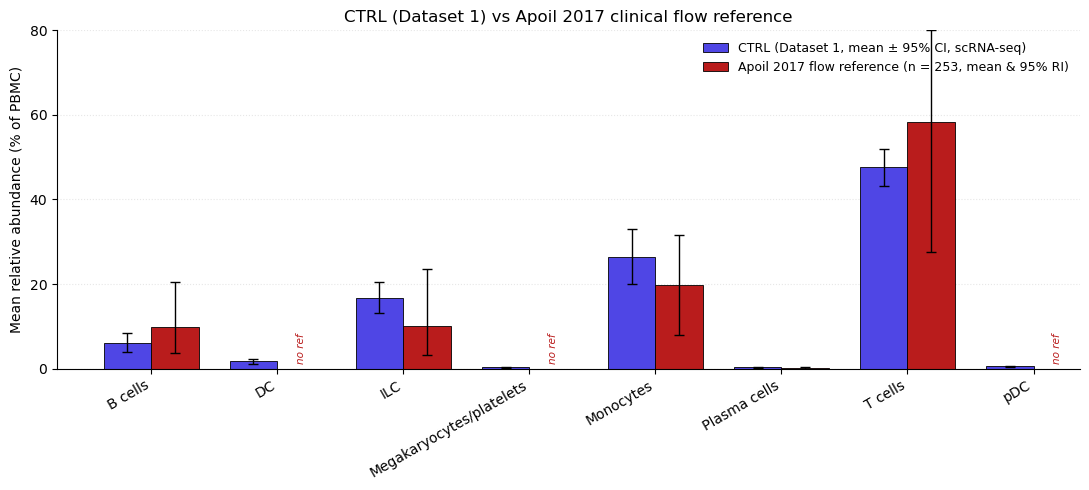

In [71]:
# ---------- Apoil 2017 reference, scaled to % of PBMC ----------
# PBMC denominator: Apoil lymph (2012/µL) + clinical mono ref (500/µL)
# + Autissier DCs (15/µL) ≈ 2527 cells/µL
PBMC_MEAN = 2012 + 500 + 15

# cluster, mean_count, lo_count, hi_count
apoil_rows = [
    ("T cells",                   1473,  700, 2508),
    ("B cells",                    247,   92,  515),
    ("ILC",                        253,   82,  594),
    ("Monocytes",                  500,  200,  800),   # clinical reference, not Apoil
    ("Plasma cells",               3.2,  0.5, 12.4),   # Apoil plasmablasts × B count
    ("DC",                        None, None, None),   # not covered
    ("pDC",                       None, None, None),
    ("Megakaryocytes/platelets",  None, None, None),
]
apoil_ref = pd.DataFrame(
    apoil_rows,
    columns=["celltypist_cell_label_coarse", "mean_count", "lo_count", "hi_count"],
)
apoil_ref["apoil_mean"] = apoil_ref["mean_count"] / PBMC_MEAN * 100
apoil_ref["apoil_lo"]   = apoil_ref["lo_count"]   / PBMC_MEAN * 100
apoil_ref["apoil_hi"]   = apoil_ref["hi_count"]   / PBMC_MEAN * 100
# cap the T-cell upper bound at ~80 so the y axis doesn't break
apoil_ref.loc[apoil_ref["celltypist_cell_label_coarse"] == "T cells", "apoil_hi"] = 80.0

# ---------- aggregate your CTRL: mean + 95% CI per cluster ----------
ctrl_stats = (
    ctrl_plot_df
    .groupby("celltypist_cell_label_coarse", observed=True)["rel_abundance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
ctrl_stats["ci95"] = 1.96 * ctrl_stats["std"] / np.sqrt(ctrl_stats["count"])

# merge, keeping CTRL order as the x-axis
df = (
    ctrl_stats
    .merge(apoil_ref, on="celltypist_cell_label_coarse", how="left")
    .rename(columns={"mean": "ctrl_mean"})
)

# ---------- paired bar plot ----------
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.38

# your CTRL (blue) — mean ± 95% CI
ax.bar(
    x - w/2, df["ctrl_mean"], w,
    yerr=df["ci95"], capsize=3.5,
    color="#4f46e5", edgecolor="black", linewidth=0.6,
    label="CTRL (Dataset 1, mean ± 95% CI, scRNA-seq)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# Apoil reference (red) — mean with asymmetric 95% RI
err_lo = (df["apoil_mean"] - df["apoil_lo"]).astype(float)
err_hi = (df["apoil_hi"]   - df["apoil_mean"]).astype(float)
ax.bar(
    x + w/2, df["apoil_mean"], w,
    yerr=[err_lo, err_hi], capsize=3.5,
    color="#b91c1c", edgecolor="black", linewidth=0.6,
    label="Apoil 2017 flow reference (n = 253, mean & 95% RI)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# mark clusters with no reference
for i, row in df.iterrows():
    if pd.isna(row["apoil_mean"]):
        ax.text(i + w/2, 1.2, "no ref", ha="center", va="bottom",
                rotation=90, color="#b91c1c", fontsize=7.5, style="italic")

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(df["celltypist_cell_label_coarse"], rotation=30, ha="right")
ax.set_ylabel("Mean relative abundance (% of PBMC)")
ax.set_xlabel("")
ax.set_title("CTRL (Dataset 1) vs Apoil 2017 clinical flow reference")
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 20))
ax.grid(axis="y", linestyle=":", alpha=0.3)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [72]:
# Trying scanpro for compositional analysis

from scanpro.scanpro import scanpro

In [73]:
out = scanpro(adata, samples_col='sample', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis') # default transformation is logit (can also specify transformation='arcsin')

out.results

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


,baseline_props,mean_props_PD,mean_props_CTRL,prop_ratio,t_statistics,p_values,adjusted_p_values
clusters,,,,,,,
B cells,0.048012,0.047361,0.061706,0.767519,-1.076463,0.291659,0.388879
DC,0.020830,0.022079,0.017799,1.240416,1.182153,0.247900,0.388879
ILC,0.161038,0.199398,0.168230,1.185274,0.571905,0.572324,0.654085
Megakaryocytes/platelets,0.001597,0.001481,0.002993,0.494767,-2.143761,0.041628,0.333022
Monocytes,0.298519,0.302713,0.265141,1.141708,1.226443,0.231081,0.388879
Plasma cells,0.002967,0.002713,0.002729,0.994161,0.142199,0.888025,0.888025
T cells,0.459544,0.416650,0.476186,0.874973,-1.351777,0.188151,0.388879
pDC,0.007493,0.007606,0.005217,1.457985,1.474632,0.152381,0.388879


In [74]:
out.props

celltypist_cell_label_coarse,B cells,DC,ILC,Megakaryocytes/platelets,Monocytes,Plasma cells,T cells,pDC
sample,,,,,,,,
CTRL1,0.056265,0.016785,0.102837,0.001418,0.413475,0.002128,0.403783,0.003310
CTRL2,0.022646,0.022646,0.120865,0.002290,0.420865,0.000254,0.404326,0.006107
CTRL3,0.044600,0.010747,0.124664,0.003761,0.328318,0.001075,0.484148,0.002687
CTRL4,0.060071,0.010601,0.175265,0.008481,0.318021,0.002827,0.416961,0.007774
CTRL5,0.128989,0.025266,0.166223,0.005319,0.265957,0.002660,0.400931,0.004654
CTRL6,0.049271,0.012569,0.225742,0.001508,0.239316,0.001508,0.467069,0.003017
CTRL7,0.026529,0.017986,0.150180,0.000899,0.219874,0.004496,0.574191,0.005845
CTRL8,0.108502,0.009249,0.136606,0.000711,0.188189,0.007826,0.540733,0.008182
CTRL9,0.083956,0.040440,0.170549,0.002198,0.116923,0.003956,0.581978,0.000000


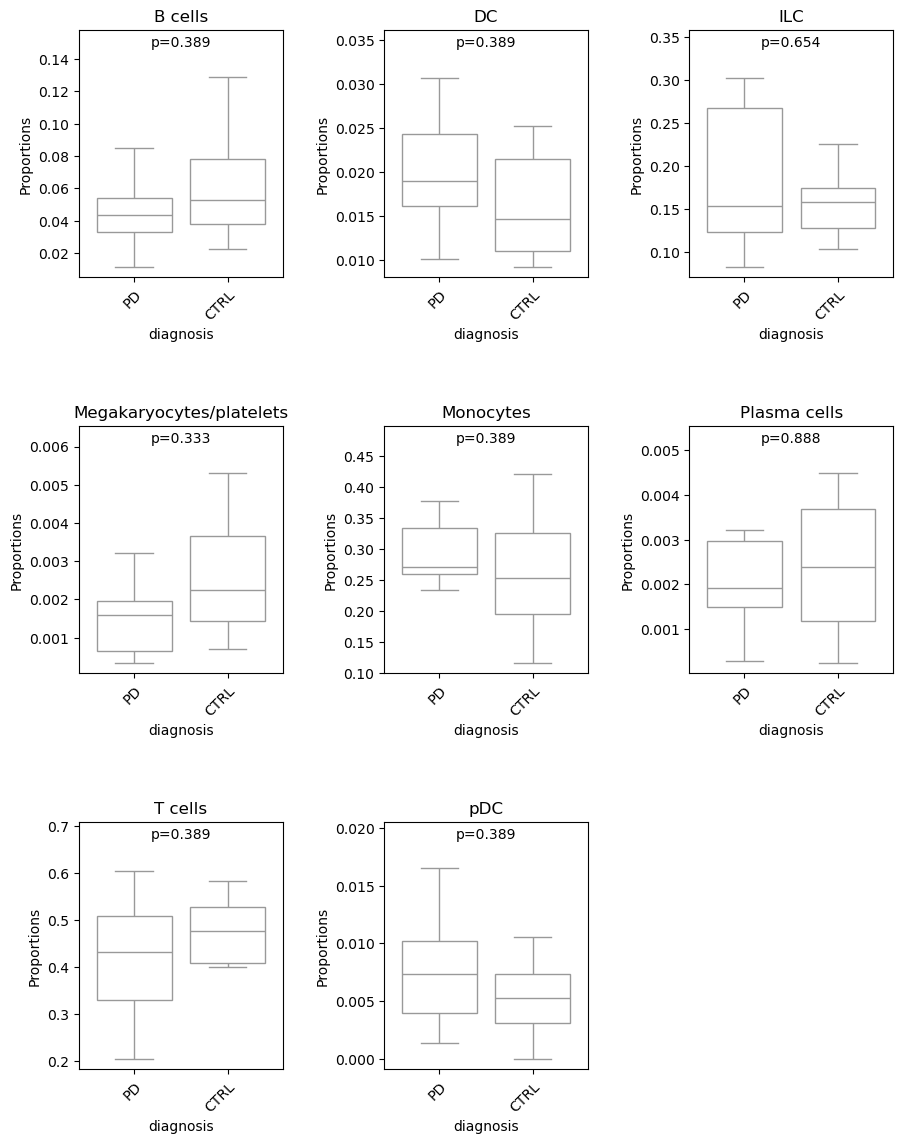

In [75]:
out.plot(kind='boxplot')

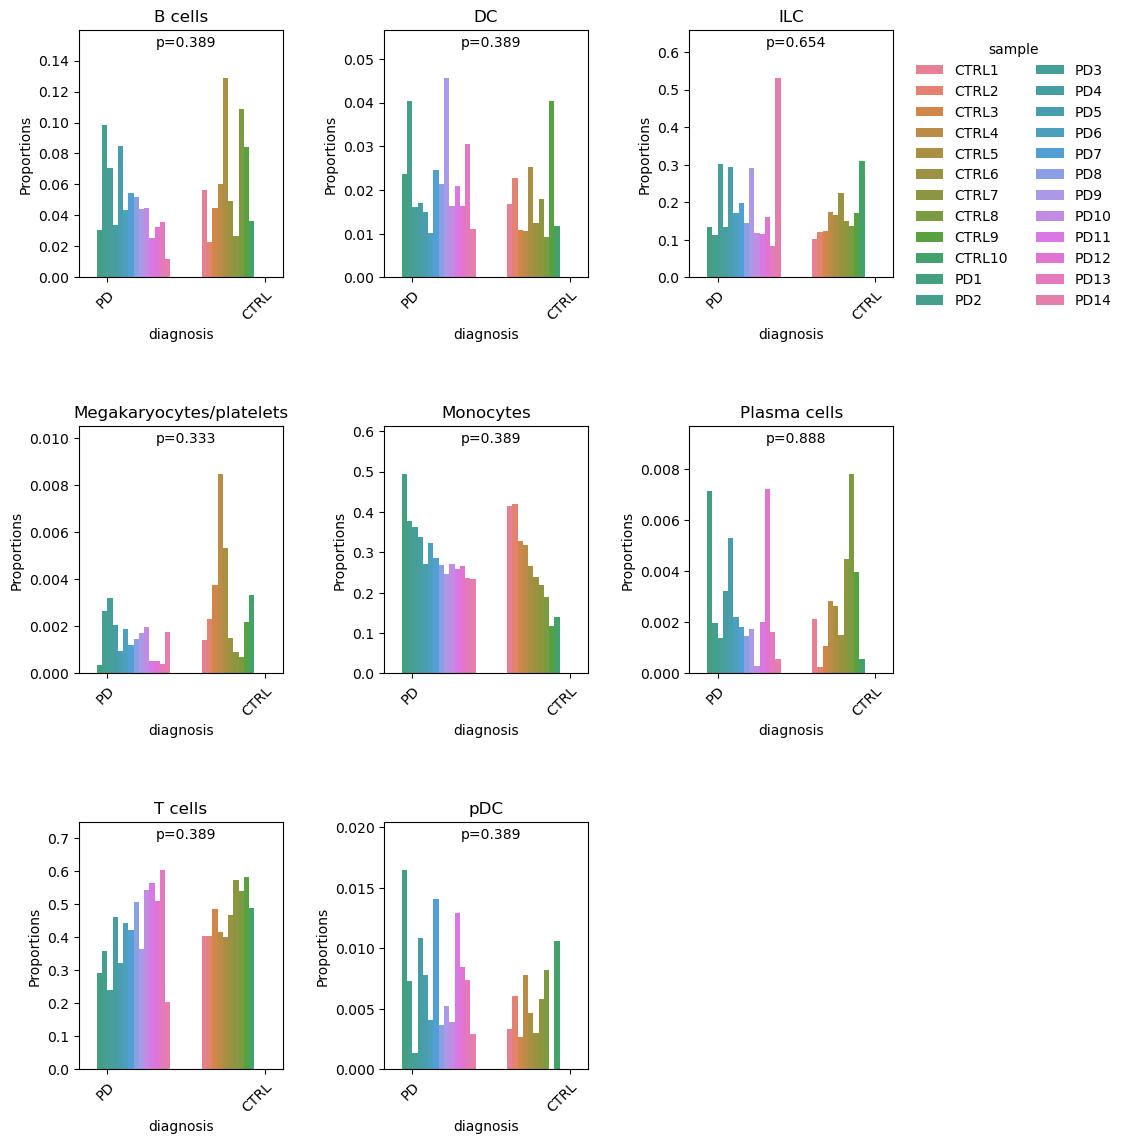

In [76]:
out.plot(kind='barplot')

In [77]:
# scanpro but with fine annotations

out = scanpro(adata, samples_col='sample', clusters_col='celltypist_cell_label_fine', conds_col='diagnosis') # default transformation is logit (can also specify transformation='arcsin')

out.results

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


,baseline_props,mean_props_PD,mean_props_CTRL,prop_ratio,t_statistics,p_values,adjusted_p_values
clusters,,,,,,,
Age-associated B cells,0.001306,0.001575,0.001327,1.186991,0.174174,0.863043,0.892262
CD16+ NK cells,0.163890,0.201668,0.171538,1.175642,0.536345,0.596161,0.766493
Classical monocytes,0.226786,0.233638,0.197991,1.180040,1.246017,0.223582,0.622549
DC1,0.001128,0.001009,0.000907,1.111894,-0.136741,0.892262,0.892262
DC2,0.019702,0.021070,0.016892,1.247320,1.155226,0.258233,0.622549
MAIT cells,0.008494,0.007692,0.011553,0.665823,-1.110494,0.276689,0.622549
Megakaryocytes/platelets,0.001597,0.001481,0.002993,0.494767,-2.137410,0.041881,0.622549
Memory B cells,0.010257,0.010767,0.013515,0.796614,-1.028859,0.312778,0.625556
Naive B cells,0.033597,0.032749,0.043555,0.751907,-1.117804,0.273609,0.622549


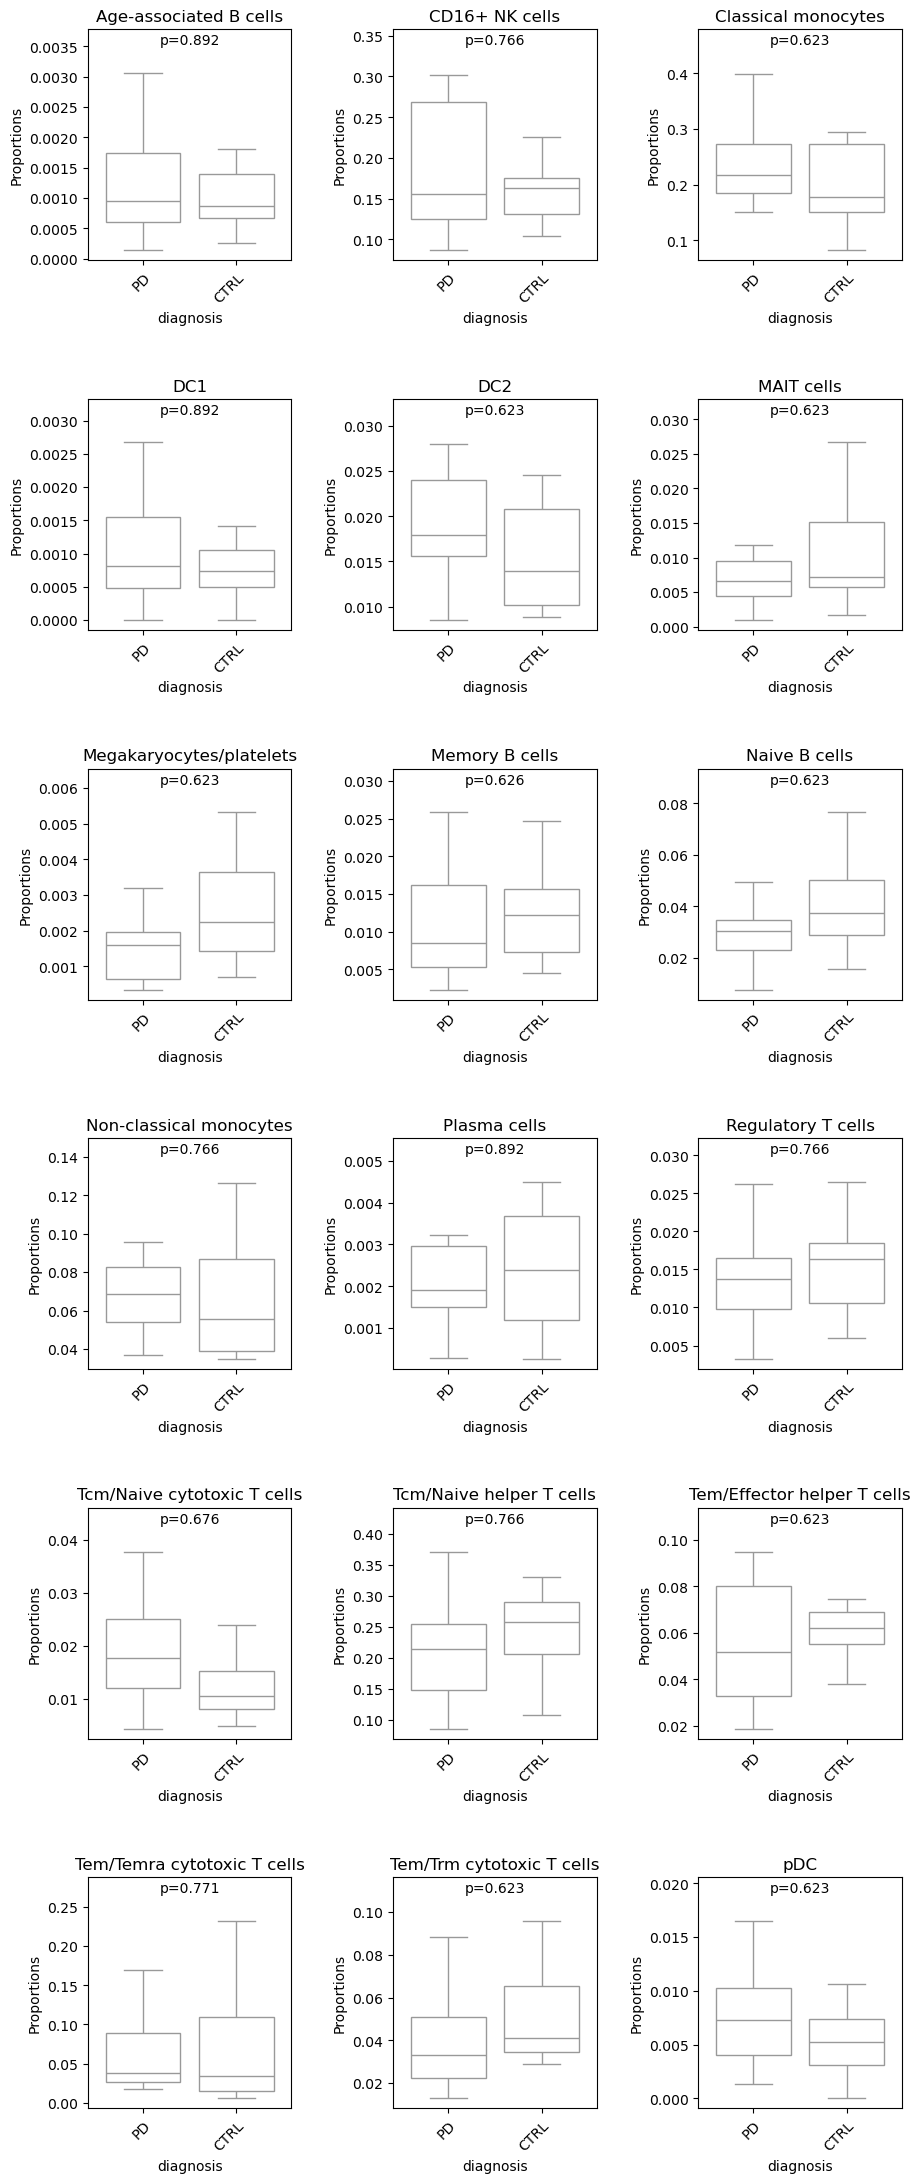

In [78]:
out.plot(kind='boxplot')

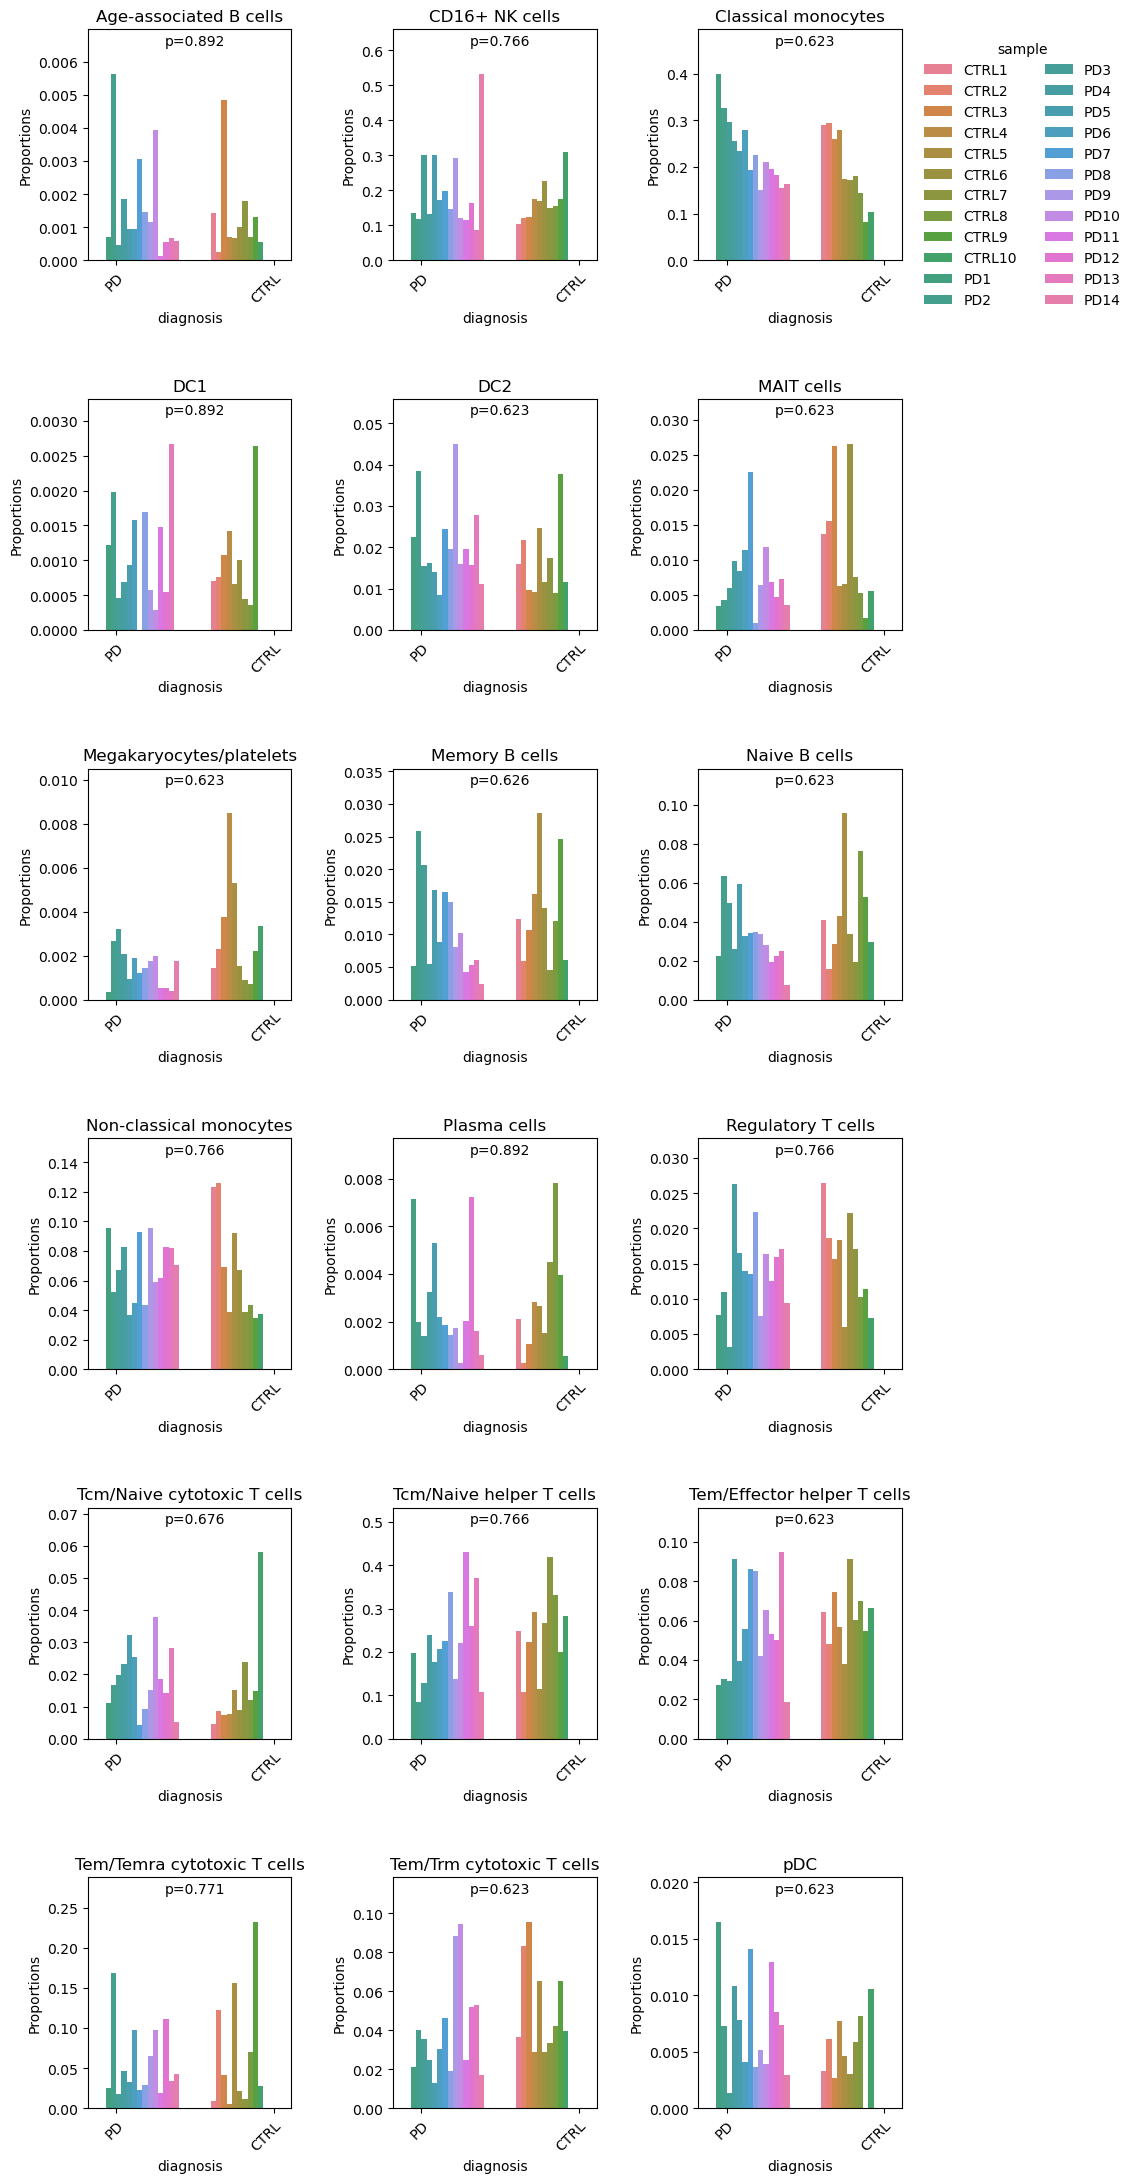

In [79]:
out.plot(kind='barplot')